In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict

/home/alex/NuMI/PELEE/


In [2]:
ending = "Mar25"

In [3]:
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_events_energy_MC_ONLY_weighted_recoCut_incErr_nuWro_'+ending+'.csv') as file:
    content = file.readlines()
events = content[0:]
    
for i in range(10):
    events[i]=events[i].rstrip().rstrip(',')
    events[i] = float(events[i])
    
print("Unsmeared events")
print(events)
print("")

nuWro_events = events

#------------------------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_AC_energy_MC_ONLY_weighted_recoCut_incErr_nuWro_'+ending+'.csv') as file:
    content = file.readlines()
AC = content[0:]
    
for i in range(100):
    AC[i]=AC[i].rstrip().rstrip(',')
    AC[i] = float(AC[i])
    

chunks = [AC[x:x+10] for x in range(0, len(AC), 10)]

print("AC")
print(chunks)
nuWro_Ac = chunks
print("")
#---------------------------------------------------------------

with open('nue_full_500_catsel_nopions_recoE_usingSelection_prior_true_signal_blockwise_recoCut_'+ending+'.csv') as file:
    content = file.readlines()
prior_true = content[0:]
    
for i in range(10):
    prior_true[i]=prior_true[i].rstrip().rstrip(',')
    prior_true[i] = float(prior_true[i])
    
print("Prior Truth: ")
print(prior_true)
print("")

#----------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_errors_energy_MC_ONLY_weighted_recoCut_incErr_nuWro_'+ending+'.csv') as file:
    content = file.readlines()
errs = content[0:]
    
for i in range(10):
    errs[i]=errs[i].rstrip().rstrip(',')
    errs[i] = float(errs[i])
    
print("Errors: ")
print(errs)
print("")
print("################################################################")
print("")

nuWro_errs = errs

#----------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_cov_matrix_energy_MC_ONLY_weighted_recoCut_incErr_nuWro_'+ending+'.csv') as file:
    content = file.readlines()
cov = content[0:]
    
for i in range(100):
    cov[i]=cov[i].rstrip().rstrip(',')
    cov[i] = float(cov[i])
    

chunks_cov = [cov[x:x+10] for x in range(0, len(cov), 10)]

print("cov")
print(chunks_cov)
print("")

Unsmeared events
[74.1539, 163.781, 74.9011, 32.9944, 16.0263, 1105.6, 1419.93, 589.292, 1262.87, 179.81]

AC
[[0.177105, 0.231023, 0.114551, 0.0697497, 0.0217742, 0.0022689, 0.0, 0.0, 0.0, 0.0], [0.231023, 0.619216, 0.254886, 0.185223, 0.0446926, 0.00323275, 0.0, 0.0, 0.0, 0.0], [0.114551, 0.254886, 0.293026, -0.0730124, -0.0165763, -2.8074e-05, 0.0, 0.0, 0.0, 0.0], [0.0697497, 0.185223, -0.0730124, 0.184007, -0.0118974, -0.000805268, 0.0, 0.0, 0.0, 0.0], [0.0217742, 0.0446926, -0.0165763, -0.0118974, 0.45929, 0.000366516, 0.0, 0.0, 0.0, 0.0], [0.0022689, 0.00323275, -2.8074e-05, -0.000805268, 0.000366516, 0.291126, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.533829, 0.26705, 0.324847, 0.0440871], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.26705, 0.23432, 0.19506, 0.0255784], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.324847, 0.19506, 0.304607, 0.0425819], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0440871, 0.0255784, 0.0425819, 0.00597987]]

Prior Truth: 
[76.99765905691928, 186.6880399358794, 90.116897

In [4]:
with open('../blockwise/stv-analysis-new/blocks_10.txt') as file:
    content = file.readlines()
blocks = content[0:]

print(blocks)

['10\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  1\n', '7  1\n', '8  1\n', '9  1\n', '10\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  1\n', '7  1\n', '8  1\n', '9  1\n']


In [5]:

made_data_sig = np.dot(prior_true, chunks)
print("Prior_Truth x AC: ")
print(made_data_sig)
print("")
print("")
print("Unfolding Done with MC Data Signal: ")
print(events)
print("")

diff = made_data_sig - events
print("")
print("Difference")
print(diff)

print("")
diffasfrac = np.nan_to_num(diff/made_data_sig)
print(diffasfrac*100)

Prior_Truth x AC: 
[  73.05745201  167.66074525   80.28459748   37.27949624   18.29220858
  446.34241123 1975.53289067 1199.5381441  1371.11154647  185.80491539]


Unfolding Done with MC Data Signal: 
[74.1539, 163.781, 74.9011, 32.9944, 16.0263, 1105.6, 1419.93, 589.292, 1262.87, 179.81]


Difference
[  -1.09644799    3.87974525    5.38349748    4.28509624    2.26590858
 -659.25758877  555.60289067  610.2461441   108.24154647    5.99491539]

[  -1.50080239    2.31404509    6.70551719   11.49451219   12.38728811
 -147.70220624   28.12420351   50.8734255     7.89443767    3.22645683]


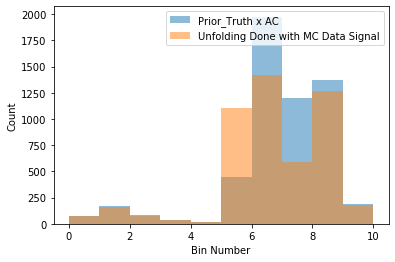

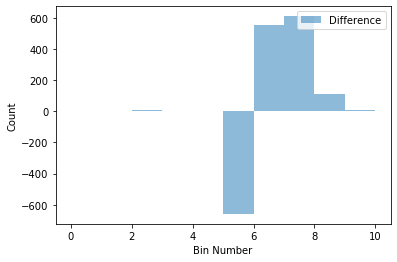

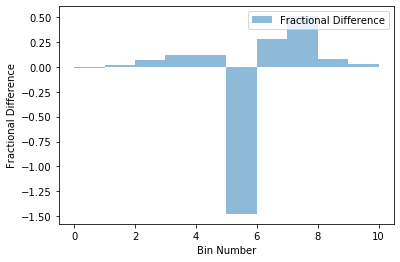

In [6]:
import random
import numpy
from matplotlib import pyplot

bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()

pyplot.hist(count, bins, weights=diff, alpha=0.5, label='Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()


pyplot.hist(count, bins, weights=diffasfrac, alpha=0.5, label='Fractional Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Fractional Difference")
pyplot.show()

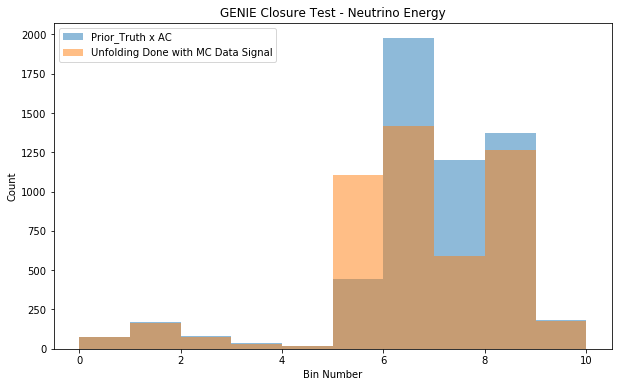

In [7]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper left')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.title("GENIE Closure Test - Neutrino Energy")
pyplot.show()

#fig.savefig("nuWro_fakeData_closure_test_energy_"+ending+".svg",bbox_inches='tight' )

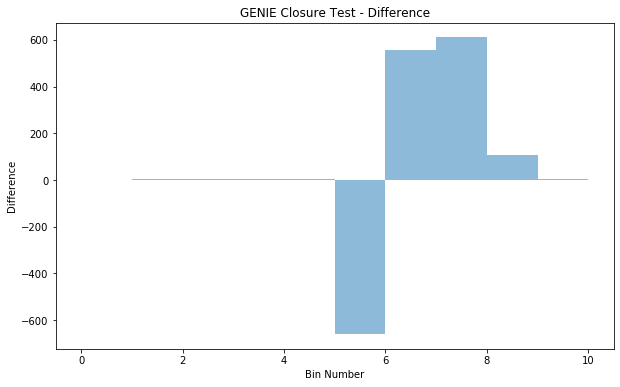

In [8]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=diff, alpha=0.5)
pyplot.xlabel("Bin Number")
pyplot.ylabel("Difference")
pyplot.title("GENIE Closure Test - Difference")
pyplot.show()

#fig.savefig("nuWro_fakeData_closure_test_diff_energy_"+ending+".svg",bbox_inches='tight' )

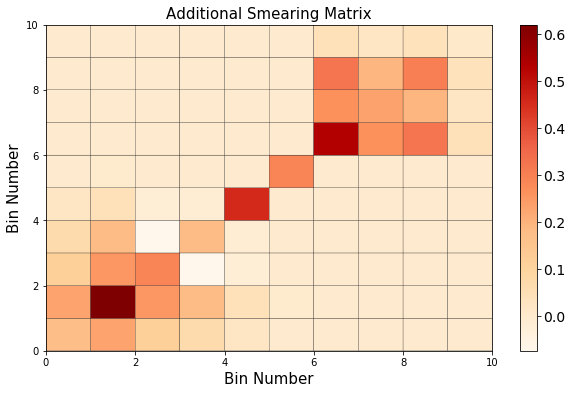

In [9]:
fig = plt.figure(figsize=(10, 6))  
    
plt.pcolor(bins, bins, chunks, cmap='OrRd', edgecolors='k')
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title('Additional Smearing Matrix', fontsize=15)

plt.show()

fig.savefig("nuWro_fakeData_closure_test_Ac_energy_"+ending+".svg",bbox_inches='tight' )

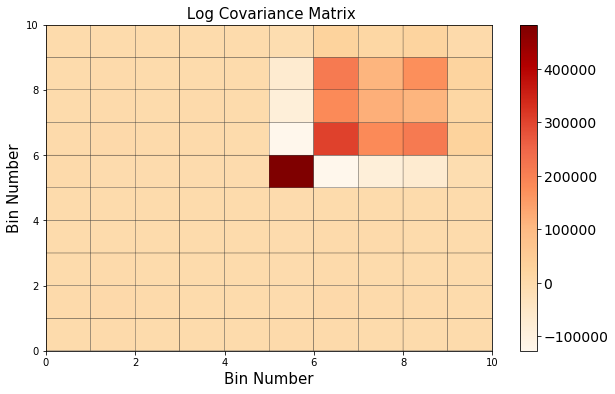

In [10]:
fig = plt.figure(figsize=(10, 6))  

bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)
    
plt.pcolor(bins, bins, (chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

In [11]:
test = np.diag(chunks_cov)
print(test)
print("")
print(np.sqrt(test))

[6.55754e+02 3.53555e+03 8.44339e+02 2.65015e+02 4.56873e+01 4.82597e+05
 3.05975e+05 1.20382e+05 1.73265e+05 3.37195e+03]

[ 25.60769416  59.46049108  29.05751194  16.27928131   6.75923812
 694.69201809 553.15007005 346.96109292 416.25112612  58.06849404]


In [12]:
np.savetxt("data_covmat_MC_nuWro_chi2_recoE_comb_"+ending+".csv", 
           chunks_cov,
           delimiter =", ", 
           fmt ='% s')

print(ending)

Mar25


## Actual comparison needed

Need to compare the unfolded signal w/err to the nuWro true selected signal x Ac

In [13]:
print(nuWro_events)
print(nuWro_errs)

[74.1539, 163.781, 74.9011, 32.9944, 16.0263, 1105.6, 1419.93, 589.292, 1262.87, 179.81]
[25.6077, 59.4605, 29.0575, 16.2793, 6.75924, 694.692, 553.15, 346.961, 416.251, 58.0685]


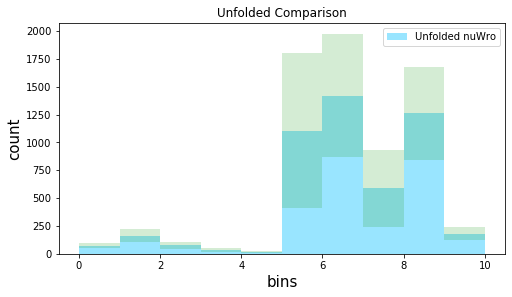

In [14]:
###############
###BOTH######
#############

nue_unf_fig = plt.figure(figsize=(8, 7))
nue_unf_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_unf_ax1 = plt.subplot(nue_unf_gs[0])


bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)
bincenters = np.arange(0.5, 10.5, 1)
bin_size = [0.5]*10

sel = nue_unf_ax1.hist(count, bins, color='deepskyblue', weights=nuWro_events, alpha = 0.4, label="Unfolded nuWro")  # , weights=xsec_ratio_events

errors = nue_unf_ax1.bar(bincenters, np.array(nuWro_errs)*2,width=[n*2 for n in bin_size],facecolor='tab:green',alpha=0.2,bottom=(np.array(nuWro_events) - np.array(nuWro_errs)))


nue_unf_ax1.set_ylabel('count', fontsize=15)
nue_unf_ax1.set_xlabel('bins', fontsize=15)
nue_unf_ax1.set_title("Unfolded Comparison")
leg = nue_unf_ax1.legend()

In [15]:
nue_nuWro_true = pd.read_csv("nue_nuWro_prior_true_run1_energy_"+ending+".csv", header=None)

nue_nuWro_true = nue_nuWro_true.values[:, 0]
print(nue_nuWro_true)
print("")
#########################################

numu_nuWro_true = pd.read_csv("numu_nuWro_prior_true_run1_energy_"+ending+".csv", header=None)

numu_nuWro_true = numu_nuWro_true.values[:, 0]
print(numu_nuWro_true)

[ 63.51210613 167.29315505  80.17903868  25.30124539  18.46750466]

[1440.11346981 2069.5197778  1678.04460228  890.58201194  640.23509148]


In [17]:
nue_numu_tot_nuWro_true = np.concatenate((nue_nuWro_true, numu_nuWro_true), axis=0)

print(nue_numu_tot_nuWro_true)

[  63.51210613  167.29315505   80.17903868   25.30124539   18.46750466
 1440.11346981 2069.5197778  1678.04460228  890.58201194  640.23509148]



'\nnue_numu_tot_nuWro_true_err = np.concatenate((nue_nuWro_true_err, numu_nuWro_true_err), axis=0)\n\nprint(nue_numu_tot_nuWro_true_err)\n\n'

In [19]:
#Now smear it by Ac

smeared_nuWro = np.dot(nue_numu_tot_nuWro_true, nuWro_Ac)
print("Prior_Truth x AC: ")
print(smeared_nuWro)
print("")
print("")
print("Unfolding Done with MC Data Signal: ")
print(nuWro_events)
print("")

diff = smeared_nuWro - events
print("")
print("Difference")
print(diff)

print("")
diffasfrac = np.nan_to_num(diff/smeared_nuWro)
print(diffasfrac*100)

Prior_Truth x AC: 
[  64.51581004  148.86713024   71.21674409   32.83864004   16.23936537
  419.92353698 1870.42048783 1135.95778438 1298.13661293  175.91201824]


Unfolding Done with MC Data Signal: 
[74.1539, 163.781, 74.9011, 32.9944, 16.0263, 1105.6, 1419.93, 589.292, 1262.87, 179.81]


Difference
[-9.63808996e+00 -1.49138698e+01 -3.68435591e+00 -1.55759960e-01
  2.13065369e-01 -6.85676463e+02  4.50490488e+02  5.46665784e+02
  3.52666129e+01 -3.89798176e+00]

[ -14.9391133   -10.01824226   -5.17344055   -0.47431915    1.31203014
 -163.28602772   24.08498467   48.12377642    2.71671044   -2.21587007]


unfolded =  [  74.1539  163.781    74.9011   32.9944   16.0263 1105.6    1419.93
  589.292  1262.87    179.81  ]
smeared =  [  64.51581004  148.86713024   71.21674409   32.83864004   16.23936537
  419.92353698 1870.42048783 1135.95778438 1298.13661293  175.91201824]


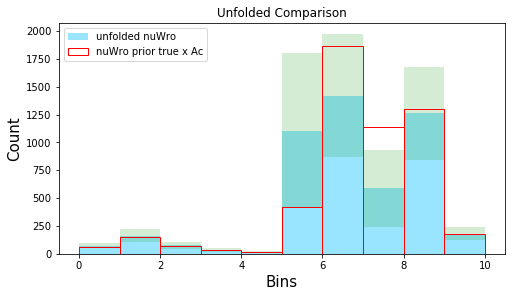

In [21]:
###############
###NUE######
#############

nue_unf_fig = plt.figure(figsize=(8, 7))
nue_unf_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_unf_ax1 = plt.subplot(nue_unf_gs[0])


bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)
bincenters = np.arange(0.5, 10.5, 1)
bin_size = [0.5]*10

f_obs = nue_unf_ax1.hist(count, bins, color='deepskyblue', weights=nuWro_events, alpha = 0.4, label="unfolded nuWro")  # , weights=xsec_ratio_events

errors = nue_unf_ax1.bar(bincenters, np.array(nuWro_errs)*2,width=[n*2 for n in bin_size],facecolor='tab:green',alpha=0.2,bottom=(np.array(nuWro_events) - np.array(nuWro_errs)))

f_exp = nue_unf_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=smeared_nuWro, label='nuWro prior true x Ac')


print("unfolded = ", f_obs[0])
print("smeared = ", f_exp[0])

nue_unf_ax1.set_ylabel('Count', fontsize=15)
nue_unf_ax1.set_xlabel('Bins', fontsize=15)
nue_unf_ax1.set_title("Unfolded Comparison")
leg = nue_unf_ax1.legend()

nue_unf_fig.savefig("unfolded_MC_nuWro_output_recoE_comb_"+ending+".svg", bbox_inches='tight')

In [22]:
np.savetxt("data_signal_MC_nuWro_chi2_recoE_comb_"+ending+".csv", 
               nuWro_events,
               delimiter =", ", 
               fmt ='% s')

np.savetxt("prior_true_MC_nuWro_chi2_recoE_comb_"+ending+".csv", 
               smeared_nuWro,
               delimiter =", ", 
               fmt ='% s')

print(ending)

Mar25


In [24]:
for i in np.arange(len(smeared_nuWro)):
    print("bin = ", i)
    if( ((smeared_nuWro[i] < nuWro_events[i] + nuWro_errs[i]) and (smeared_nuWro[i] > nuWro_events[i] - nuWro_errs[i]))):# or ((nuWro_events[i] < smeared_nuWro[i] + nue_numu_tot_nuWro_true_err[i]) and (nuWro_events[i] > smeared_nuWro[i] - nue_numu_tot_nuWro_true_err[i])) ):
        print("Inside")
        print("")
    else:
        print("outside")
        print("value is (genie) = ", smeared_nuWro[i])
        print("top of err = ", nuWro_events[i] + nuWro_errs[i])
        print("bot of err = ", nuWro_events[i] - nuWro_errs[i])
        print("")

bin =  0
Inside

bin =  1
Inside

bin =  2
Inside

bin =  3
Inside

bin =  4
Inside

bin =  5
Inside

bin =  6
Inside

bin =  7
outside
value is (genie) =  1135.9577843794107
top of err =  936.253
bot of err =  242.33100000000002

bin =  8
Inside

bin =  9
Inside



In [25]:
f_obs = f_obs[0]
f_exp = f_exp[0]

In [26]:
###Do a chi squared test

import scipy.stats as sp

print(sum(f_obs))
print(sum(f_exp))


4919.3587
5234.028130146336


In [27]:
hold = []

for i in range(10):   
    braket = (f_obs[i] - f_exp[i])
    num = (braket*braket)/f_exp[i]
    hold.append(num)
    
print("final value = ", sum(hold))
chi_squared_stat = sum(hold)

final value =  1495.3632052762814


In [28]:
####Crital value - what the chi sqaured value must be below for a P value of this significance

deg_of_free = 9*9

sp.chi2.ppf(q = 0.5, df = deg_of_free)

80.3343176062148

In [29]:
p_value = 1 - sp.chi2.cdf(x=chi_squared_stat,  # Find the p-value
                             df=deg_of_free)
print("P value:",p_value)

P value: 0.0


In [67]:
#####up to 11 has really good p value, 

In [68]:
##Now try Katrina's way - seems to match Stevens

In [30]:
inverse_unfcov = np.linalg.inv(chunks_cov)

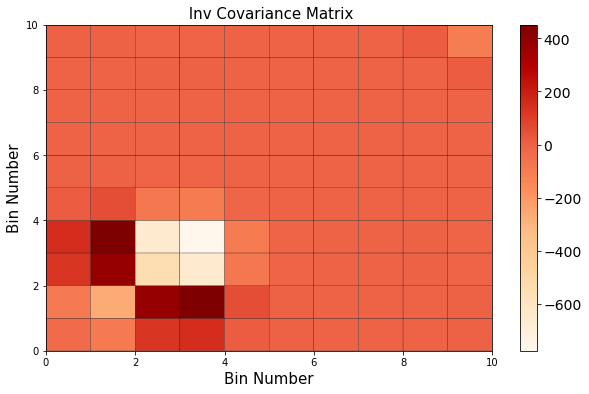

In [31]:
fig = plt.figure(figsize=(10, 6))  

bins = np.arange(0, 11, 1)
count = np.arange(0.0, 10.0, 1)
    
plt.pcolor(bins, bins, inverse_unfcov , cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Inv Covariance Matrix', fontsize=15)

plt.show()

In [32]:
chi2_genie = 0

print(len(bins)-1)
print(len(f_obs))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs)): 

            print(( (f_obs[i]-f_exp[i])*inverse_unfcov[i][j]*(f_obs[j]-f_exp[j]) ))
            chi2_genie = chi2_genie  + ( (f_obs[i]-f_exp[i])*inverse_unfcov[i][j]*(f_obs[j]-f_exp[j]) )
            print("chi2 genie = ", chi2_genie)
            print("------------------")
  

10
10
-2668.1673906993487
chi2 genie =  -2668.1673906993487
------------------
-12527.033715342279
chi2 genie =  -15195.201106041628
------------------
4456.68573524323
chi2 genie =  -10738.515370798399
------------------
224.9779655400521
chi2 genie =  -10513.537405258347
------------------
-37.54993644985194
chi2 genie =  -10551.087341708198
------------------
10547.124177406742
chi2 genie =  -3.963164301456345
------------------
-0.6966932337464353
chi2 genie =  -4.6598575352027805
------------------
-154.0503272674971
chi2 genie =  -158.71018480269987
------------------
97.31404067553524
chi2 genie =  -61.39614412716463
------------------
71.90556194490438
chi2 genie =  10.509417817739745
------------------
-12527.03371533839
chi2 genie =  -12516.52429752065
------------------
-58432.77926275775
chi2 genie =  -70949.30356027841
------------------
20806.339931034916
chi2 genie =  -50142.96362924349
------------------
1050.17426467631
chi2 genie =  -49092.78936456718
----------------

In [33]:
chi2_genie

6.477922576709034

In [34]:
p_value = 1 - sp.chi2.cdf(x=chi2_genie,  # Find the p-value
                             df=9)
print("P value:",p_value)

P value: 0.691295279337665


## Values from Steven's Code which takes uncertainty into account

In [37]:
deg_of_free = 11

sp.chi2.ppf(q = 0.01, df = deg_of_free)

3.05348410664068